# California Housing Price Prediction

This notebook is a practice machine learning regression project.

The goal is to predict California housing prices using district-level features, then choose a good final model that can be saved and used later in a FastAPI app.

The workflow is simple:

1. Load and inspect the data
2. Build preprocessing pipelines
3. Train and compare models
4. Analyze model errors
5. Use cross-validation and tuning
6. Save the final model pipeline


In [84]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.dummy import DummyRegressor
import warnings
warnings.filterwarnings("ignore")

## 1. Load the Dataset

The dataset is loaded from the local `data` folder.

I start by checking the shape of the data and previewing the first rows to understand the available columns.


In [85]:
df=pd.read_csv("../data/housing.csv")

print(df.shape)

df.head()

(20640, 10)


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


## 2. Initial Data Inspection

Before training any model, I inspect the dataset structure.

This step helps me check column types, missing values, and the general quality of the data.


In [86]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [87]:
df.describe(include="all")

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,5
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,<1H OCEAN
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,9136
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909,NaN
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874,NaN
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000,NaN
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000,NaN
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000,NaN
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000,NaN


## 3. Checking Capped Values

Some columns may contain capped values, such as `median_house_value = 500001`.

This is important because capped values can make expensive houses harder to predict accurately.


In [88]:
print((df["median_house_value"] == 500001).sum())
print((df["median_income"] == 15.0001).sum())
print((df["housing_median_age"] == 52).sum())

965
49
1273


## 4. Duplicate and Missing Value Checks

Here I check for duplicated rows and missing values.

This is a basic but important step before creating the preprocessing pipeline.


In [89]:
df.duplicated().sum()

np.int64(0)

In [90]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

## 5. Categorical Feature Exploration

The `ocean_proximity` column is the main categorical feature.

I check its categories and distribution because location can have a strong effect on housing prices.


ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


<Axes: xlabel='ocean_proximity', ylabel='count'>

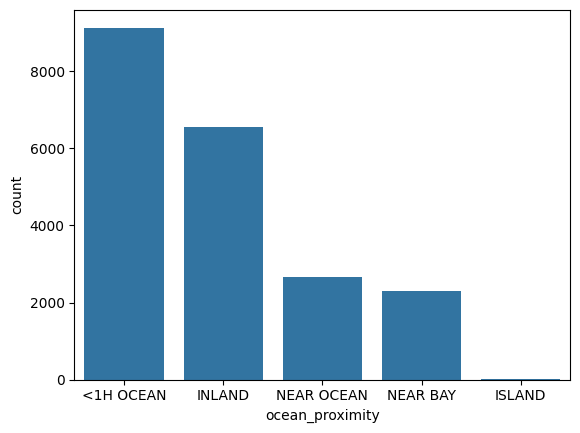

In [91]:
print(df["ocean_proximity"].value_counts())

sns.countplot(
    x="ocean_proximity",
    data=df,
    order=df["ocean_proximity"].value_counts().index
)

## 6. Numerical Feature Distributions

Histograms help show the distribution of each numerical column.

This makes it easier to notice skewed data, unusual values, and capped features.


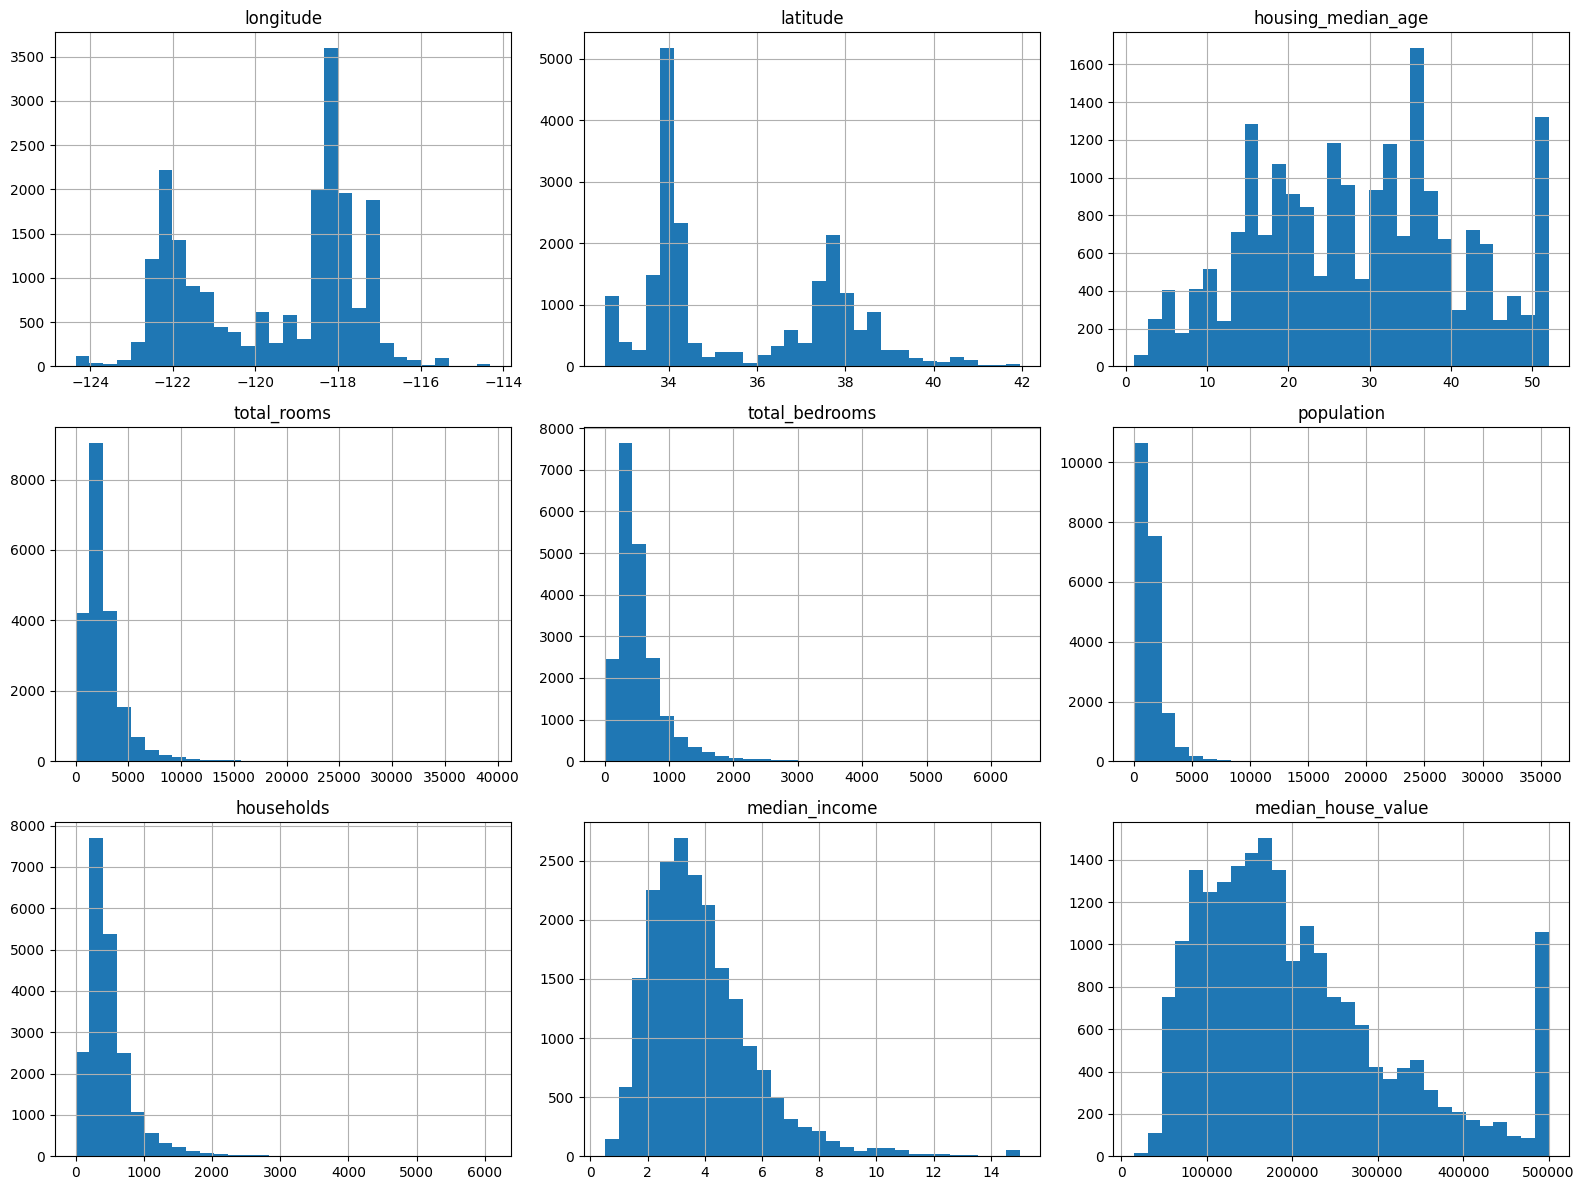

In [92]:
numeric_cols = df.select_dtypes(include="number").columns

df[numeric_cols].hist(figsize=(16, 12), bins=30)

plt.tight_layout()
plt.show()

## 7. Split Features and Target

The target column is `median_house_value`.

All other columns are used as input features.


In [93]:
x = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

## 8. Train-Test Split

The data is split into training and testing sets.

The training set is used to train the models, while the test set is kept for final evaluation.


In [94]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42)
x_train.shape ,x_test.shape ,y_train.shape ,y_test.shape 

((16512, 9), (4128, 9), (16512,), (4128,))

## 9. Define Numerical and Categorical Columns

I separate numerical and categorical columns so each type can have the right preprocessing steps.


In [95]:
num_features = x.select_dtypes(include="number").columns
cat_features = x.select_dtypes(exclude="number").columns

## 10. Build Preprocessing Pipelines

For numerical columns, missing values are filled using the median and the data is scaled.

For categorical columns, missing values are filled using the most frequent value and then encoded using one-hot encoding.


In [96]:
num_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

cat_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

## 11. Combine Preprocessing Steps

`ColumnTransformer` combines the numerical and categorical preprocessing into one object.

This keeps the workflow cleaner and makes it easier to use the same preprocessing during training and prediction.


In [97]:
preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

## 12. Linear Regression Model

I start with Linear Regression as a simple model.

It is not expected to be the best model, but it gives a useful first benchmark.


In [98]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

## 13. Make Predictions

After training the Linear Regression model, I generate predictions for both the training and testing sets.


In [99]:
train_preds = model.predict(x_train)
test_preds = model.predict(x_test)

## 14. Linear Regression Evaluation

The model is evaluated using:

- MAE
- RMSE
- R² Score

These metrics help measure the average error and how much of the target variation the model explains.


In [100]:
print("Train MAE:", mean_absolute_error(y_train, train_preds))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_preds)))
print("Train R2 Score:", r2_score(y_train, train_preds))

print("\n")

print("Test MAE:", mean_absolute_error(y_test, test_preds))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
print("Test R2 Score:", r2_score(y_test, test_preds))

Train MAE: 49594.842094724365
Train RMSE: 68433.93736666226
Train R2 Score: 0.6496648627123224


Test MAE: 50670.48923565362
Test RMSE: 70059.19333925014
Test R2 Score: 0.6254382675296266


### Linear Regression Result

Linear Regression performed better than a simple average prediction, but the error was still high.

This suggests that the dataset has useful patterns, but a linear model may be too simple for the full problem.


## 15. Dummy Regressor Baseline

A `DummyRegressor` is used as a simple baseline.

It predicts the average target value from the training data and does not learn from the features.

If a real model cannot beat this baseline, it is not useful.


In [101]:
Dummy_Reg = DummyRegressor(strategy="mean")
Dummy_Reg.fit(x_train, y_train)
dummy_preds = Dummy_Reg.predict(x_test)
print("Dummy Regressor MAE:", mean_absolute_error(y_test, dummy_preds))
print("Dummy Regressor RMSE:", np.sqrt(mean_squared_error(y_test, dummy_preds)))
print("Dummy Regressor R2 Score:", r2_score(y_test, dummy_preds))

Dummy Regressor MAE: 90606.8549000715
Dummy Regressor RMSE: 114485.63543099792
Dummy Regressor R2 Score: -0.00021908714592466794


### Baseline Result

The Linear Regression model clearly beats the Dummy Regressor baseline.

This means the features are useful and the model is learning real signal from the data.


## 16. Target Distribution

I inspect the target variable to better understand the price range and distribution.

This also helps confirm that there are capped values in the target.


In [102]:
y_train.describe()

count     16512.000000
mean     207194.693738
std      115622.626448
min       14999.000000
25%      119800.000000
50%      179850.000000
75%      265125.000000
max      500001.000000
Name: median_house_value, dtype: float64

<Axes: >

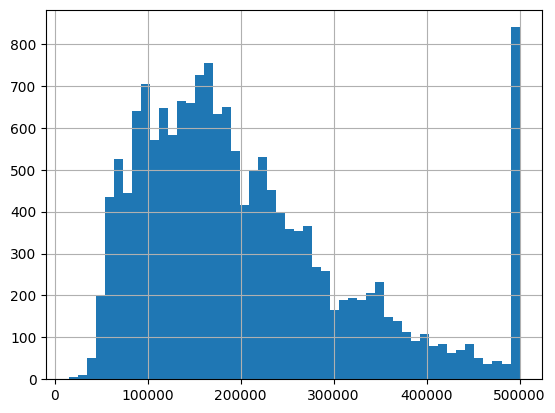

In [103]:
y_train.hist(bins=50)

## 17. Actual vs Predicted Plot

This plot compares the real house values with the model predictions.

It helps show where the Linear Regression model performs well and where it struggles.


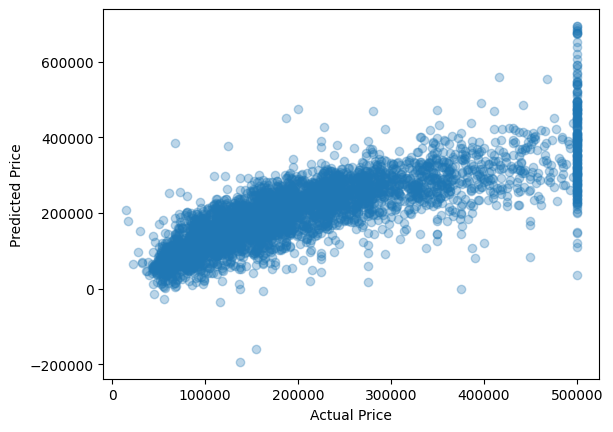

In [104]:
plt.scatter(y_test, test_preds, alpha=0.3)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.show()

## 18. Capped Target Analysis

I count how many rows have the maximum capped value of `500001`.

This helps measure how much the capped target may affect the model.


In [105]:
cap_count = (df["median_house_value"] == 500001).sum()
cap_ratio = cap_count / len(df) * 100

print("Capped values count:", cap_count)
print("Capped values percentage:", cap_ratio)

Capped values count: 965
Capped values percentage: 4.675387596899225


In [106]:
cap_train_count = (y_train == 500001).sum()
cap_train_ratio = cap_train_count / len(y_train) * 100

print("Train capped count:", cap_train_count)
print("Train capped percentage:", cap_train_ratio)

Train capped count: 786
Train capped percentage: 4.7601744186046515


## 19. Error on Capped vs Non-Capped Houses

Here I compare the Linear Regression error on capped houses and normal houses.

This shows whether the model struggles more with expensive or capped properties.


In [107]:
cap_mask = (y_test == 500001).to_numpy()

capped_mae = mean_absolute_error(y_test[cap_mask], test_preds[cap_mask])

print("Capped Test MAE:", capped_mae)
print("Capped rows in test:", cap_mask.sum())

Capped Test MAE: 140004.5799611976
Capped rows in test: 179


In [108]:
non_cap_mask = (y_test != 500001).to_numpy()

non_capped_mae = mean_absolute_error(y_test[non_cap_mask], test_preds[non_cap_mask])

print("Non-capped Test MAE:", non_capped_mae)
print("Non-capped rows in test:", non_cap_mask.sum())

Non-capped Test MAE: 46621.15972441726
Non-capped rows in test: 3949


### Capped Value Result

The error on capped houses is much higher than on non-capped houses.

This shows that expensive houses are harder for the Linear Regression model to predict.


## 20. Build an Error DataFrame

I create a small dataframe that contains:

- actual values
- predicted values
- absolute errors

This makes error analysis easier.


In [109]:
error_df = pd.DataFrame({
    "actual": y_test.values,
    "predicted": test_preds
})

error_df["abs_error"] = np.abs(error_df["actual"] - error_df["predicted"])

error_df.head()

,actual,predicted,abs_error
0,47700.0,54261.027690,6561.027690
1,45800.0,124430.917728,78630.917728
2,500001.0,255694.958282,244306.041718
3,218600.0,268208.010360,49608.010360
4,278000.0,262975.013606,15024.986394


## 21. Group Errors by Price Range

To understand the model better, I divide house prices into ranges.

This helps check whether the error increases for more expensive houses.


In [110]:
def get_price_range(price):
    if price < 100000:
        return "0-100k"
    elif price < 200000:
        return "100k-200k"
    elif price < 300000:
        return "200k-300k"
    elif price < 400000:
        return "300k-400k"
    elif price < 500000:
        return "400k-500k"
    else:
        return "500k+"

In [111]:
error_df["price_range"] = error_df["actual"].apply(get_price_range)

error_df.head()

,actual,predicted,abs_error,price_range
0,47700.0,54261.027690,6561.027690,0-100k
1,45800.0,124430.917728,78630.917728,0-100k
2,500001.0,255694.958282,244306.041718,500k+
3,218600.0,268208.010360,49608.010360,200k-300k
4,278000.0,262975.013606,15024.986394,200k-300k


In [112]:
range_errors = error_df.groupby("price_range")["abs_error"].agg(["count", "mean"])

print(range_errors)

             count           mean
price_range                      
0-100k         730   37365.232143
100k-200k     1684   42418.501160
200k-300k      956   38823.077642
300k-400k      415   67599.681903
400k-500k      159  120990.615808
500k+          184  141587.858794


## 22. Residual Analysis

Residuals are calculated as:

`actual value - predicted value`

This helps identify whether the model is overpredicting or underpredicting in different price ranges.


In [113]:
error_df["residual"] = error_df["actual"] - error_df["predicted"]

In [114]:
range_bias = error_df.groupby("price_range").agg(
    count=("abs_error", "count"),
    mae=("abs_error", "mean"),
    actual_mean=("actual", "mean"),
    predicted_mean=("predicted", "mean"),
    residual_mean=("residual", "mean")
)

print(range_bias)

             count            mae    actual_mean  predicted_mean  \
price_range                                                        
0-100k         730   37365.232143   75748.080822   100609.269409   
100k-200k     1684   42418.501160  151183.194774   175615.865148   
200k-300k      956   38823.077642  243994.037657   243822.329279   
300k-400k      415   67599.681903  344601.445783   284789.387616   
400k-500k      159  120990.615808  441186.163522   324527.297660   
500k+          184  141587.858794  500000.972826   391006.501587   

             residual_mean  
price_range                 
0-100k       -24861.188587  
100k-200k    -24432.670373  
200k-300k       171.708378  
300k-400k     59812.058167  
400k-500k    116658.865862  
500k+        108994.471239  


### Residual Analysis Result

The Linear Regression model tends to overpredict cheaper houses and underpredict expensive houses.

This means the predictions are being pulled toward the middle price range.


## 23. Decision Tree Regressor

Next, I train a Decision Tree model.

This model can capture nonlinear patterns, but it can also overfit easily if it is not controlled.


In [115]:
model_DT = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", DecisionTreeRegressor(random_state=42))
])

model_DT.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [116]:
dt_train_preds = model_DT.predict(x_train)
dt_test_preds = model_DT.predict(x_test)

print("Train MAE:", mean_absolute_error(y_train, dt_train_preds))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, dt_train_preds)))
print("Train R2 Score:", r2_score(y_train, dt_train_preds))

print("\n")

print("Test MAE:", mean_absolute_error(y_test, dt_test_preds))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, dt_test_preds)))
print("Test R2 Score:", r2_score(y_test, dt_test_preds))

Train MAE: 0.0
Train RMSE: 0.0
Train R2 Score: 1.0


Test MAE: 43604.01429263566
Test RMSE: 69175.76918851306
Test R2 Score: 0.6348249193739326


### Decision Tree Result

The Decision Tree overfits the training data strongly.

However, its test error is better than Linear Regression, which suggests that nonlinear models are more suitable for this dataset.


## 24. Random Forest Regressor

Random Forest uses many decision trees and averages their predictions.

This usually reduces overfitting compared to a single decision tree and often gives better results.


In [117]:
model_RF = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(n_estimators=100, random_state=42,n_jobs=-1))
])

model_RF.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [118]:
rf_train_preds = model_RF.predict(x_train)
rf_test_preds = model_RF.predict(x_test)

print("Train MAE:", mean_absolute_error(y_train, rf_train_preds))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, rf_train_preds)))
print("Train R2 Score:", r2_score(y_train, rf_train_preds))

print("\n")

print("Test MAE:", mean_absolute_error(y_test, rf_test_preds))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, rf_test_preds)))
print("Test R2 Score:", r2_score(y_test, rf_test_preds))

Train MAE: 11641.438696705425
Train RMSE: 18073.213368485107
Train R2 Score: 0.9755650534559848


Test MAE: 31628.40731104651
Test RMSE: 48941.70034309343
Test R2 Score: 0.8172104989933294


### Random Forest Result

Random Forest gives a clear improvement compared to Linear Regression and Decision Tree.

This makes it the strongest model so far.


## 25. Feature Engineering Experiment

I create a few simple ratio-based features:

- `rooms_per_household`
- `bedrooms_ratio`
- `people_per_household`

These features may give more useful information than raw totals alone.


In [119]:
df["rooms_per_household"] = df["total_rooms"] / df["households"]

df["bedrooms_ratio"] = df["total_bedrooms"] / df["total_rooms"]

df["people_per_household"] = df["population"] / df["households"]

## 26. Random Forest with Engineered Features

After adding the new features, I rebuild the feature matrix and preprocessing pipeline.

This is important because the model will not use new columns unless the preprocessing step is updated.


In [120]:
X = df.drop("median_house_value", axis=1)
y = df["median_house_value"]

x_train, x_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object"]).columns

preprocessor = ColumnTransformer(transformers=[
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

model_RF = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

model_RF.fit(x_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [121]:
rf_train_preds = model_RF.predict(x_train)
rf_test_preds = model_RF.predict(x_test)

print("Train MAE:", mean_absolute_error(y_train, rf_train_preds))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, rf_train_preds)))
print("Train R2 Score:", r2_score(y_train, rf_train_preds))

print("\n")

print("Test MAE:", mean_absolute_error(y_test, rf_test_preds))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, rf_test_preds)))
print("Test R2 Score:", r2_score(y_test, rf_test_preds))

Train MAE: 11983.917335271317
Train RMSE: 18530.280861164556
Train R2 Score: 0.9743135169495319


Test MAE: 31926.269672965114
Test RMSE: 49833.73239428686
Test R2 Score: 0.810486578954982


### Feature Engineering Result

The engineered features did not improve Random Forest in this experiment.

They are still useful to test because they show how feature engineering can affect different model types.


## 27. Linear Regression with Engineered Features

I also test the engineered features with Linear Regression.

Simple models can sometimes benefit more from manually created features.


In [124]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

model.fit(x_train, y_train)

train_preds = model.predict(x_train)
test_preds = model.predict(x_test)

print("Train MAE:", mean_absolute_error(y_train, train_preds))
print("Train RMSE:", np.sqrt(mean_squared_error(y_train, train_preds)))
print("Train R2 Score:", r2_score(y_train, train_preds))

print("\n")

print("Test MAE:", mean_absolute_error(y_test, test_preds))
print("Test RMSE:", np.sqrt(mean_squared_error(y_test, test_preds)))
print("Test R2 Score:", r2_score(y_test, test_preds))

Train MAE: 48785.16002488509
Train RMSE: 67593.20745775253
Train R2 Score: 0.6582199160539229


Test MAE: 49645.49244453642
Test RMSE: 69127.03829924985
Test R2 Score: 0.635339233523819


### Linear Regression Feature Engineering Result

The engineered features slightly improved Linear Regression.

This is expected because linear models often benefit from manually created features.


## 28. Prepare Base and Engineered Feature Sets

To compare fairly, I create two versions of the input data:

- `X_base`: original features only
- `X_fe`: original features plus engineered features


In [125]:
base_features = [
    "longitude",
    "latitude",
    "housing_median_age",
    "total_rooms",
    "total_bedrooms",
    "population",
    "households",
    "median_income",
    "ocean_proximity"
]

engineered_features = [
    "rooms_per_household",
    "bedrooms_ratio",
    "people_per_household"
]

X_base = df[base_features]
X_fe = df[base_features + engineered_features]
y = df["median_house_value"]

## 29. Train-Test Split for Comparison

Both feature sets are split using the same random state.

This keeps the comparison between base features and engineered features fair.


In [126]:
X_base_train, X_base_test, y_train, y_test = train_test_split(
    X_base, y, test_size=0.2, random_state=42
)

X_fe_train, X_fe_test, _, _ = train_test_split(
    X_fe, y, test_size=0.2, random_state=42
)

## 30. Helper Function for Preprocessing

This function builds a preprocessing pipeline depending on the columns inside each feature set.

It avoids repeating the same preprocessing code many times.


In [127]:
def build_preprocessor(X):
    num_features = X.select_dtypes(include=["int64", "float64"]).columns
    cat_features = X.select_dtypes(include=["object"]).columns
    
    preprocessor = ColumnTransformer(transformers=[
        ("num", num_pipeline, num_features),
        ("cat", cat_pipeline, cat_features)
    ])
    
    return preprocessor

## 31. Cross-Validation Function

Cross-validation gives a more reliable comparison than using only one train-test split.

The function reports the average MAE, RMSE, and R² across several folds.


In [128]:
from sklearn.model_selection import cross_val_score, KFold

def evaluate_cv(model, X_train, y_train, cv=5):
    kfold = KFold(n_splits=cv, shuffle=True, random_state=42)
    
    mae_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_mean_absolute_error",
        cv=kfold,
        n_jobs=-1
    )
    
    rmse_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="neg_root_mean_squared_error",
        cv=kfold,
        n_jobs=-1
    )
    
    r2_scores = cross_val_score(
        model,
        X_train,
        y_train,
        scoring="r2",
        cv=kfold,
        n_jobs=-1
    )
    
    print("MAE:", -mae_scores.mean(), "+/-", mae_scores.std())
    print("RMSE:", -rmse_scores.mean(), "+/-", rmse_scores.std())
    print("R2:", r2_scores.mean(), "+/-", r2_scores.std())

## 32. Cross-Validation: Linear Regression with Base Features

I first evaluate Linear Regression using only the original features.


In [129]:
linear_base = Pipeline(steps=[
    ("preprocessor", build_preprocessor(X_base_train)),
    ("regressor", LinearRegression())
])

evaluate_cv(linear_base, X_base_train, y_train)

MAE: 49667.15906724984 +/- 1005.2971483624566
RMSE: 68604.16295529755 +/- 1324.9472102500545
R2: 0.6476757451183028 +/- 0.013200064780817615


## 33. Cross-Validation: Linear Regression with Engineered Features

Now I check whether the engineered features improve Linear Regression.


In [130]:
linear_fe = Pipeline(steps=[
    ("preprocessor", build_preprocessor(X_fe_train)),
    ("regressor", LinearRegression())
])

evaluate_cv(linear_fe, X_fe_train, y_train)

MAE: 48879.908800710095 +/- 982.3483017944143
RMSE: 67858.77852206837 +/- 1312.1722875689238
R2: 0.6552367818548062 +/- 0.014270128074664058


## 34. Cross-Validation: Random Forest with Base Features

Random Forest is evaluated using the original features.

This version later becomes the best choice based on cross-validation.


In [131]:
rf_base = Pipeline(steps=[
    ("preprocessor", build_preprocessor(X_base_train)),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_cv(rf_base, X_base_train, y_train)

MAE: 32328.532730978925 +/- 545.4013966535264
RMSE: 49445.28603543163 +/- 1212.9954782219083
R2: 0.8170755514674996 +/- 0.005359998045694038


## 35. Cross-Validation: Random Forest with Engineered Features

I also evaluate Random Forest with the engineered features.

This checks whether the new features help or hurt the stronger model.


In [132]:
rf_fe = Pipeline(steps=[
    ("preprocessor", build_preprocessor(X_fe_train)),
    ("regressor", RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=-1
    ))
])

evaluate_cv(rf_fe, X_fe_train, y_train)

MAE: 32911.44872622487 +/- 517.0182398942271
RMSE: 50299.453186193925 +/- 1027.9657473658144
R2: 0.8106844857549993 +/- 0.004892124347657855


### Cross-Validation Result

Cross-validation showed that Random Forest with the original features performed better than Random Forest with the engineered features.

For this reason, the final model uses the base feature set.


## 36. Hyperparameter Tuning

I use `RandomizedSearchCV` to tune the Random Forest model.

The goal is to test different hyperparameter combinations and improve validation performance without trying every possible option.


In [133]:
from sklearn.model_selection import RandomizedSearchCV

rf_base_tuning = Pipeline(steps=[
    ("preprocessor", build_preprocessor(X_base_train)),
    ("regressor", RandomForestRegressor(
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    "regressor__n_estimators": [100, 200, 300],
    "regressor__max_depth": [None, 10, 20, 30, 40],
    "regressor__min_samples_split": [2, 5, 10],
    "regressor__min_samples_leaf": [1, 2, 4],
    "regressor__max_features": ["sqrt", 0.5, 0.7, 1.0]
}

random_search = RandomizedSearchCV(
    estimator=rf_base_tuning,
    param_distributions=param_distributions,
    n_iter=20,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=2
)

random_search.fit(X_base_train, y_train)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


,"estimator estimator: estimator objectAn object of that type is instantiated for each grid point.This is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step...m_state=42))])
,"param_distributions param_distributions: dict or list of dictsDictionary with parameters names (`str`) as keys and distributionsor lists of parameters to try. Distributions must provide a ``rvs``method for sampling (such as those from scipy.stats.distributions).If a list is given, it is sampled uniformly.If a list of dicts is given, first a dict is sampled uniformly, andthen a parameter is sampled using that dict as above.","{'regressor__max_depth': [None, 10, ...], 'regressor__max_features': ['sqrt', 0.5, ...], 'regressor__min_samples_leaf': [1, 2, ...], 'regressor__min_samples_split': [2, 5, ...], ...}"
,"n_iter n_iter: int, default=10Number of parameter settings that are sampled. n_iter tradesoff runtime vs quality of the solution.",20
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.If None, the estimator's score method is used.",'neg_mean_absolute_error'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given the ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``RandomizedSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide 

## 37. Best Parameters

After tuning, I print the best hyperparameters and the best cross-validation MAE.


In [134]:
print("Best Params:")
print(random_search.best_params_)

print("\nBest CV MAE:")
print(-random_search.best_score_)

Best Params:
{'regressor__n_estimators': 200, 'regressor__min_samples_split': 2, 'regressor__min_samples_leaf': 1, 'regressor__max_features': 0.7, 'regressor__max_depth': None}

Best CV MAE:
32026.56804814282


## 38. Final Model Evaluation

The best tuned model is evaluated on the test set.

This is the final model performance after model comparison and tuning.


In [135]:
best_model = random_search.best_estimator_

final_train_preds = best_model.predict(X_base_train)
final_test_preds = best_model.predict(X_base_test)

print("Final Train MAE:", mean_absolute_error(y_train, final_train_preds))
print("Final Train RMSE:", np.sqrt(mean_squared_error(y_train, final_train_preds)))
print("Final Train R2:", r2_score(y_train, final_train_preds))

print("\n")

print("Final Test MAE:", mean_absolute_error(y_test, final_test_preds))
print("Final Test RMSE:", np.sqrt(mean_squared_error(y_test, final_test_preds)))
print("Final Test R2:", r2_score(y_test, final_test_preds))

Final Train MAE: 11525.462350411823
Final Train RMSE: 17716.527900374705
Final Train R2: 0.9765200122146965


Final Test MAE: 31377.3981189438
Final Test RMSE: 48471.692778036464
Final Test R2: 0.8207044487803845


### Final Result

The tuned Random Forest is selected as the final model.

It gives the best overall performance and generalizes better than the simpler models.


## 39. Save the Final Pipeline

The final model is saved using `joblib`.

Saving the full pipeline is useful because it includes both preprocessing and the trained model.

This saved file can be loaded later inside the FastAPI app.


In [136]:
import joblib
import os

os.makedirs("../model", exist_ok=True)

joblib.dump(best_model, "../model/housing_price_model.joblib")

['../model/housing_price_model.joblib']

## 40. Test the Saved Model

Finally, I load the saved model and test it on one sample.

This confirms that the saved pipeline works correctly before using it in the web app.


In [137]:
loaded_model = joblib.load("../model/housing_price_model.joblib")

sample = X_base_test.iloc[[0]]
loaded_pred = loaded_model.predict(sample)

print("Prediction:", loaded_pred[0])
print("Actual:", y_test.iloc[0])

Prediction: 49893.0
Actual: 47700.0


## Final Notes

This project helped me practice the full machine learning workflow, not just model training.

The main lessons from this notebook:

- A baseline model is important before judging any model.
- Linear Regression was useful, but too simple for this dataset.
- Error analysis showed that expensive houses were harder to predict.
- Decision Tree captured nonlinear patterns but overfit badly.
- Random Forest gave the best balance between performance and generalization.
- Cross-validation gave a more reliable model comparison.
- Saving the full pipeline made the model ready for deployment.
